# Stage 6: Feature Importance (MDI / weighted MDA / weighted SFI)

Uses the **tuned** RF parameters from `models/best_params.json` (produced by Stage 5). MDA permutes each feature in the test fold and re-scores with the corrected weighted-scoring path; SFI inherits weighted scoring through `cv_score`. Bottom-25% intersection across all three rankings is dropped, and the reduced model is refit and saved as `model_final.pkl`.

In [1]:
import sys, os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

sys.path.append('../')
from src.cross_validation import PurgedKFold
from src.modelling import train_and_evaluate
from src.feature_importance import (
    feat_imp_MDI, feat_imp_MDA, feat_imp_SFI, plot_feature_importance,
)

plt.style.use('seaborn-v0_8-darkgrid')
RNG = 42
os.makedirs('../reports/figures', exist_ok=True)

## 1. Load dataset and tuned params

In [2]:
dataset = pd.read_parquet('../data/processed/nvda_modelling_dataset.parquet')
X = dataset.drop(columns=['label', 'weight', 't1'])
y = dataset['label'].astype(int)
sample_weight = dataset['weight']
t1 = dataset['t1']

with open('../models/best_params.json') as f:
    best = json.load(f)
rf_params = best['rf']['params']
rf_params = {k: (None if v == 'None' else v) for k, v in rf_params.items()}
print('Tuned RF params:', rf_params)

majority_baseline = float((y == y.mode()[0]).mean())
print(f'majority-class baseline accuracy: {majority_baseline:.4f}')

pkf = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)

Tuned RF params: {'n_estimators': 100, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 7, 'class_weight': None}
majority-class baseline accuracy: 0.5846


## 2. Fit tuned RF on full data

In [3]:
rf = RandomForestClassifier(**rf_params, random_state=RNG, n_jobs=-1)
rf.fit(X, y, sample_weight=sample_weight.values)
rf

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3. MDI

In [4]:
mdi = feat_imp_MDI(rf, X.columns); mdi.round(4)

,mean,std
amihud_illiquidity,0.1144,0.0181
roll_spread,0.1054,0.0191
log_dollar_volume,0.0977,0.0172
vol_50d,0.0949,0.0173
fracdiff,0.0860,0.0180
volume_ratio,0.0853,0.0177
vol_20d,0.0668,0.0157
ret_20d,0.0628,0.0150
ret_5d,0.0540,0.0158
ret_10d,0.0475,0.0122


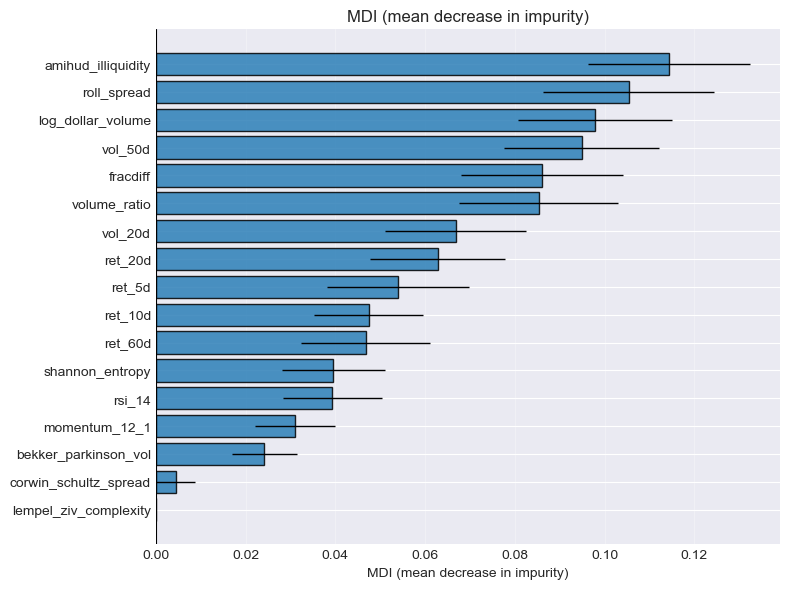

In [5]:
fig = plot_feature_importance(mdi, 'MDI (mean decrease in impurity)', color='#2c7fb8')
fig.savefig('../reports/figures/P15_mdi_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. MDA — weighted neg_log_loss permutation

Both the baseline and per-feature permuted scores honour the test-fold sample weights, so the MDA delta is computed on a like-for-like basis.

In [6]:
mda = feat_imp_MDA(
    clf=rf, X=X, y=y, cv=pkf,
    sample_weight=sample_weight, scoring='neg_log_loss', random_state=RNG,
)
mda.round(4)

,mean,std
ret_10d,0.0042,0.0024
amihud_illiquidity,0.0033,0.0019
shannon_entropy,0.0024,0.0015
volume_ratio,0.0022,0.0067
log_dollar_volume,0.0015,0.0013
ret_20d,0.0011,0.0015
ret_5d,0.0005,0.0015
rsi_14,0.0004,0.0010
vol_50d,0.0001,0.0045
fracdiff,0.0001,0.0010


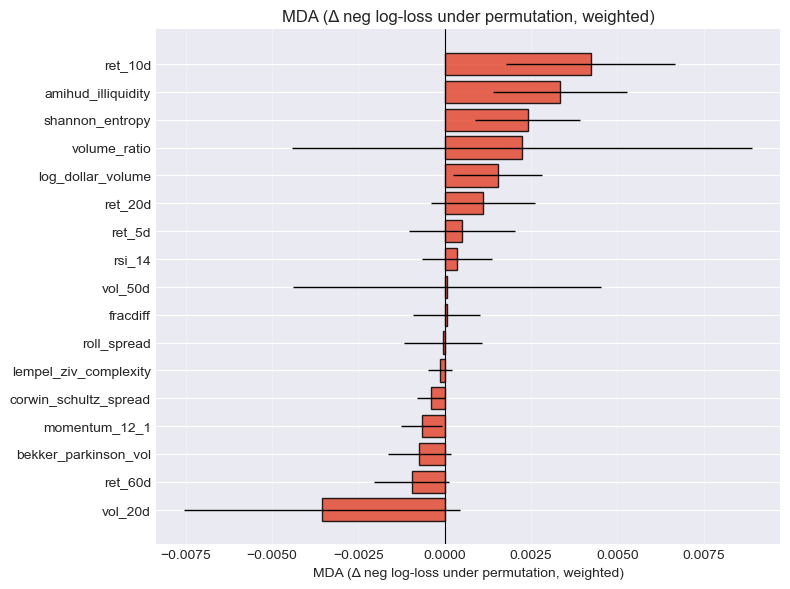

In [7]:
fig = plot_feature_importance(mda, 'MDA (Δ neg log-loss under permutation, weighted)',
                              color='#e34a33')
fig.savefig('../reports/figures/P16_mda_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SFI — weighted single-feature CV

In [8]:
sfi_template = RandomForestClassifier(**rf_params, random_state=RNG, n_jobs=-1)
sfi = feat_imp_SFI(
    clf_template=sfi_template, X=X, y=y, cv=pkf,
    sample_weight=sample_weight, scoring='neg_log_loss',
)
sfi.round(4)

,mean,std
log_dollar_volume,-0.6635,0.0265
amihud_illiquidity,-0.6678,0.0281
fracdiff,-0.6695,0.0249
ret_5d,-0.6718,0.0289
ret_20d,-0.6749,0.0141
lempel_ziv_complexity,-0.6759,0.0164
roll_spread,-0.6761,0.0189
shannon_entropy,-0.6762,0.0227
corwin_schultz_spread,-0.6766,0.0196
volume_ratio,-0.6818,0.0183


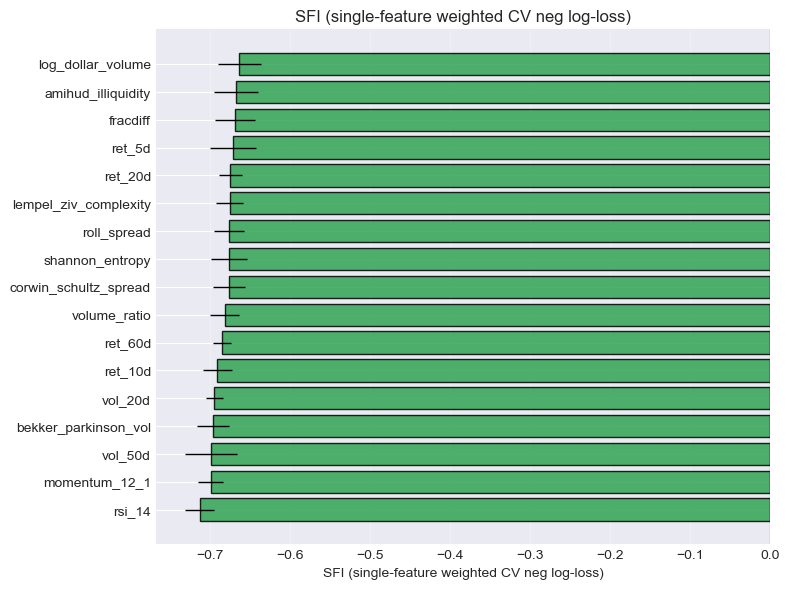

In [9]:
fig = plot_feature_importance(sfi, 'SFI (single-feature weighted CV neg log-loss)',
                              color='#31a354')
fig.savefig('../reports/figures/P17_sfi_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Rank comparison and Spearman correlation

In [10]:
rank_df = pd.DataFrame({
    'MDI_rank': mdi['mean'].rank(ascending=False).astype(int),
    'MDA_rank': mda['mean'].rank(ascending=False).astype(int),
    'SFI_rank': sfi['mean'].rank(ascending=False).astype(int),
}).reindex(X.columns)
rank_df['avg_rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')
rank_df

,MDI_rank,MDA_rank,SFI_rank,avg_rank
amihud_illiquidity,1,2,2,1.666667
log_dollar_volume,3,5,1,3.000000
fracdiff,5,10,3,6.000000
ret_20d,8,6,5,6.333333
volume_ratio,6,4,10,6.666667
roll_spread,2,11,7,6.666667
ret_5d,9,7,4,6.666667
ret_10d,10,1,12,7.666667
shannon_entropy,12,3,8,7.666667
vol_50d,4,9,15,9.333333


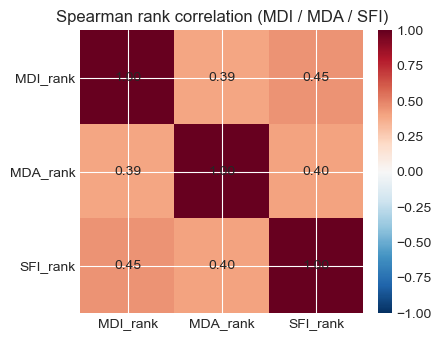

In [11]:
rank_corr = rank_df[['MDI_rank', 'MDA_rank', 'SFI_rank']].corr(method='spearman')
fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(rank_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(rank_corr.columns); ax.set_yticklabels(rank_corr.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{rank_corr.values[i, j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Spearman rank correlation (MDI / MDA / SFI)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 7. Bottom-25% intersection rule

Drop a feature only if it is in the bottom 25 % on **all three** rankings.

In [12]:
n_features = len(X.columns)
bottom_n = max(1, int(np.ceil(n_features * 0.25)))
bottom_threshold = n_features - bottom_n + 1
is_bottom = (rank_df[['MDI_rank', 'MDA_rank', 'SFI_rank']] >= bottom_threshold)
drop_features = list(rank_df.index[is_bottom.all(axis=1)])
keep_features = [c for c in X.columns if c not in drop_features]
print(f'features dropped ({len(drop_features)}): {drop_features}')
print(f'features kept    ({len(keep_features)}): {keep_features}')

features dropped (2): ['momentum_12_1', 'bekker_parkinson_vol']
features kept    (15): ['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'rsi_14', 'vol_20d', 'vol_50d', 'log_dollar_volume', 'volume_ratio', 'corwin_schultz_spread', 'amihud_illiquidity', 'roll_spread', 'shannon_entropy', 'lempel_ziv_complexity', 'fracdiff']


## 8. Refit reduced model

In [13]:
X_red = X[keep_features]
rf_full_template = RandomForestClassifier(**rf_params, random_state=RNG, n_jobs=-1)
rf_red_template  = RandomForestClassifier(**rf_params, random_state=RNG, n_jobs=-1)

result_full = train_and_evaluate(rf_full_template, X,     y, sample_weight,
                                 cv=PurgedKFold(5, t1=t1, pct_embargo=0.01),
                                 scoring='accuracy')
result_red  = train_and_evaluate(rf_red_template,  X_red, y, sample_weight,
                                 cv=PurgedKFold(5, t1=t1, pct_embargo=0.01),
                                 scoring='accuracy')

compare = pd.DataFrame({
    'mean_acc':   [result_full['mean_score'], result_red['mean_score']],
    'std_acc':    [result_full['std_score'],  result_red['std_score']],
    'n_features': [X.shape[1], X_red.shape[1]],
    'beats_baseline': [result_full['mean_score'] > majority_baseline,
                      result_red['mean_score']  > majority_baseline],
}, index=['full', 'reduced']).round(4)
compare

,mean_acc,std_acc,n_features,beats_baseline
full,0.6280,0.0716,17,True
reduced,0.6411,0.0928,15,True


## 9. Persist artefacts

In [14]:
feature_importance = pd.concat({'MDI': mdi, 'MDA': mda, 'SFI': sfi}, axis=1)
feature_importance.columns = ['_'.join(c) for c in feature_importance.columns]
feature_importance['MDI_rank'] = rank_df['MDI_rank']
feature_importance['MDA_rank'] = rank_df['MDA_rank']
feature_importance['SFI_rank'] = rank_df['SFI_rank']
feature_importance['avg_rank'] = rank_df['avg_rank']
feature_importance['kept']     = ~feature_importance.index.isin(drop_features)
feature_importance = feature_importance.reindex(X.columns)
feature_importance.to_parquet('../data/processed/feature_importance.parquet')

with open('../models/model_final.pkl', 'wb') as f:
    pickle.dump(result_red['fitted_clf'], f)

print('Saved:')
print('  ../data/processed/feature_importance.parquet')
print('  ../models/model_final.pkl')
print('  ../reports/figures/P15_mdi_importance.png')
print('  ../reports/figures/P16_mda_importance.png')
print('  ../reports/figures/P17_sfi_importance.png')

Saved:
  ../data/processed/feature_importance.parquet
  ../models/model_final.pkl
  ../reports/figures/P15_mdi_importance.png
  ../reports/figures/P16_mda_importance.png
  ../reports/figures/P17_sfi_importance.png


## 10. Stage 4 / 5 / 6 comparison summary

Single table loading the regenerated artefacts: majority baseline, Stage 4 baseline RF / XGB, Stage 5 tuned RF / XGB, and Stage 6 reduced RF.

In [15]:
cv_results = pd.read_parquet('../data/processed/cv_results.parquet')
rf_baseline_mean  = float(cv_results.loc['mean', 'RF'])
xgb_baseline_mean = float(cv_results.loc['mean', 'XGB'])
rf_baseline_std   = float(cv_results.loc['std',  'RF'])
xgb_baseline_std  = float(cv_results.loc['std',  'XGB'])

rf_tuned_mean  = best['rf']['mean_score']
rf_tuned_std   = best['rf']['std_score']
xgb_tuned_mean = best['xgb']['mean_score']
xgb_tuned_std  = best['xgb']['std_score']

summary = pd.DataFrame([
    {'row': 'majority-class baseline',     'mean_acc': majority_baseline, 'std_acc': np.nan,
     'beats_baseline': False, 'note': 'always predict majority class'},
    {'row': 'Stage 4 RF (untuned)',        'mean_acc': rf_baseline_mean,  'std_acc': rf_baseline_std,
     'beats_baseline': rf_baseline_mean  > majority_baseline,
     'note': 'AFML-recipe params, weighted purged CV'},
    {'row': 'Stage 4 XGB (untuned)',       'mean_acc': xgb_baseline_mean, 'std_acc': xgb_baseline_std,
     'beats_baseline': xgb_baseline_mean > majority_baseline,
     'note': 'AFML-recipe params, weighted purged CV'},
    {'row': 'Stage 5 RF (tuned)',          'mean_acc': rf_tuned_mean,     'std_acc': rf_tuned_std,
     'beats_baseline': rf_tuned_mean    > majority_baseline,
     'note': '25-iter randomised search, weighted purged CV'},
    {'row': 'Stage 5 XGB (tuned)',         'mean_acc': xgb_tuned_mean,    'std_acc': xgb_tuned_std,
     'beats_baseline': xgb_tuned_mean   > majority_baseline,
     'note': '25-iter randomised search, weighted purged CV'},
    {'row': 'Stage 6 RF (reduced)',        'mean_acc': result_red['mean_score'],
     'std_acc': result_red['std_score'],
     'beats_baseline': result_red['mean_score'] > majority_baseline,
     'note': f"tuned RF on {len(keep_features)} features after pruning"},
]).set_index('row')
summary.round(4)

,mean_acc,std_acc,beats_baseline,note
row,,,,
majority-class baseline,0.5846,NaN,False,always predict majority class
Stage 4 RF (untuned),0.5240,0.0806,False,"AFML-recipe params, weighted purged CV"
Stage 4 XGB (untuned),0.5283,0.1022,False,"AFML-recipe params, weighted purged CV"
Stage 5 RF (tuned),0.6280,0.0716,True,"25-iter randomised search, weighted purged CV"
Stage 5 XGB (tuned),0.6456,0.0802,True,"25-iter randomised search, weighted purged CV"
Stage 6 RF (reduced),0.6411,0.0928,True,tuned RF on 15 features after pruning


## 11. Notes

- All accuracy numbers in this notebook are **weighted** under the   AFML uniqueness-decay scheme (both fitting and scoring).
- The DSR-on-CV-trials reported in Stage 5 corrects only for   in-sample selection bias across hyperparameter configurations.   A *strategy* DSR over realised PnL belongs to the backtesting   stage, not here.
- If the bottom-25% intersection turns out empty, the reduced   model equals the full model (as we report explicitly above).